In [1]:
from winnow_fcns import *
from sim_utils import *
import numpy as np
from pathlib import Path
import os
import csv
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
#------------------files---------------------------------------------
current_file = Path.cwd()

init_file = current_file.parent / "initial_cyrus_bits.csv"
ch1_file = current_file.parent / "ch1_cyrus.csv"
ch2_file = current_file.parent / "ch2_cyrus.csv"



def load_data(init_file, ch1_file, ch2_file):
    init = np.loadtxt(init_file, delimiter=',', dtype=int)
    ch1 = np.loadtxt(ch1_file, delimiter=',')
    ch2 = np.loadtxt(ch2_file, delimiter=',')
    return init, ch1, ch2


init_key, ch1, ch2 = load_data(init_file, ch1_file, ch2_file)


def get_curr_qber(alice_winnow, bob_winnow):
    matches = (np.array(alice_winnow._key_string.bits)  != np.array(bob_winnow._key_string.bits) )

    # Calculate percentage
    percentage = matches.mean() * 100

    return percentage


In [3]:



# def get_curr_qber(alice_winnow, bob_winnow):
#     matches = (np.array(alice_winnow._key_string.bits)  != np.array(bob_winnow._key_string.bits) )

#     # Calculate percentage
#     percentage = matches.mean() * 100

#     return percentage


# def winnow_pipeline(block_schedule, current_csv):
#     qber_list = []
#     num_pass = []

#     alice_key = MockBitBuffer(list(ch1))
#     bob_key   = MockBitBuffer(list(ch2))

#     #  initialize Alice and Bob
#     alice_winnow = Winnow(raw_key=alice_key, perm_seed=42, block_schedule=block_schedule)
#     bob_winnow = Winnow(raw_key=bob_key, perm_seed=42, block_schedule=block_schedule)
#     #use same seed so they dont shuffle keys differently!!!!

#     alice_winnow.set_block_size_schedule(block_schedule)
#     bob_winnow.set_block_size_schedule(block_schedule)
#     print(alice_winnow.get_block_size_schedule())


#     qber = get_curr_qber(alice_winnow, bob_winnow)
#     print(f"Qber before EC {qber}%")
#     qber_list.append(qber)
#     num_pass.append(alice_winnow._pass_number)

#     # start first pass
#     alice_winnow.first_pass()
#     bob_winnow.first_pass()

#     success_sample = 0
#     total_sample = 0
#     with open('corrected/cyrus_test.csv', 'w', newline='') as f:
#         # alice calculates syndrome for the first block 
#         for i in range(alice_winnow._num_of_blocks):
#             block_size = alice_winnow._block_size
#             startb = i*block_size
#             endb = block_size*(i + 1) 
#             alice_syndrome = alice_winnow.get_syndrome(i)

#             bob_winnow.fix_with_syndrome(i, alice_syndrome)

            
#     # qber = get_curr_qber(alice_winnow, bob_winnow)
#     # print(f"Qber after first pass {qber}%")
#     # qber_list.append(qber)
#     # num_pass.append(alice_winnow._pass_number)
   

#     while alice_winnow.get_num_remaining_passes() > 0:
#         # print("\nAlice internal:", alice_winnow._key_string.bits[:20])
#         # print("Bob   internal:", bob_winnow._key_string.bits[:20])


#         # print(f"Alice seed: {alice_winnow._key_string.seed}")
#         # print(f"Bob seed:   {bob_winnow._key_string.seed}") 
#         block_size  = alice_winnow._block_size
#         num_blocks  = alice_winnow._num_of_blocks
#         alice_winnow._key_string.discard_parity_bits(block_size, num_blocks)
#         bob_winnow._key_string.discard_parity_bits(block_size, num_blocks)

#         qber = get_curr_qber(alice_winnow, bob_winnow)
#         print(f"Qber {qber}%")
#         qber_list.append(qber)
#         num_pass.append(alice_winnow._pass_number)

#         alice_winnow.next_pass(permute_bits=True) 
#         bob_winnow.next_pass(permute_bits=True) 
#         print(alice_winnow.get_block_size_schedule())

#         print(f"Number of blocks during {alice_winnow._pass_number} is {alice_winnow._num_of_blocks}")

#         for i in range(alice_winnow._num_of_blocks):
#             # block_size = alice_winnow._block_size
#             # startb = i*block_size
#             # endb = block_size*(i + 1) 
#             alice_syndrome = alice_winnow.get_syndrome(i)
#             # print(f"Alice syndrome: {alice_winnow.get_syndrome(i)}")
#             # print(f"Bob   syndrome: {bob_winnow.get_syndrome(i)}")
#             # bob uses Alice's syndrome to fix his key
#             # if i % 1000 == 0:
#             #     print(f"Bob's key before fix: {bob_key.bits[startb:endb]} block {i}")
#             bob_winnow.fix_with_syndrome(i, alice_syndrome)


        

#     with open(current_csv, 'w', newline='') as f:
#         writer = csv.writer(f)
#         # Pair items into rows: [(1, 'a'), (2, 'b'), ...]
#         writer.writerows(zip(num_pass, qber_list))

    
#     return qber_list, num_pass
   








# many_block_schedules = [
#     [4,4,0,0,0,0,0,0],
#     [4,2,2,0,0,0,0,0],
#     [4,2,1,0,0,0,0,0],
#     [8,4,1,0,0,0,0,0],
#     [2,2,0,0,0,0,0,0],
#     [1,1,0,0,0,0,0,0]
# ]

# output_file_names = [
#     'qber_pass_44000000.csv',
#     'qber_pass_42200000.csv',
#     'qber_pass_42100000.csv',
#     'qber_pass_84100000.csv',
#     'qber_pass_22000000.csv',
#     'qber_pass_11000000.csv'
# ]

# qber_for_schedule = []
# num_pass_for_schedule = []


# for block_schedule, output_file in zip(many_block_schedules, output_file_names):
#     qber_list, num_pass = winnow_pipeline(block_schedule, output_file)
#     qber_for_schedule.append(qber_list)
#     num_pass_for_schedule.append(num_pass)





   

In [6]:
def winnow_pipeline(block_schedule, current_csv, rng=None, seed=None):
    alice_key = MockBitBuffer(list(ch1))
    bob_key   = MockBitBuffer(list(ch2))


    # Initialize Alice and Bob
    alice_winnow = Winnow(raw_key=alice_key, perm_seed=seed, rng=rng, block_schedule=block_schedule)
    bob_winnow = Winnow(raw_key=bob_key, perm_seed=seed, rng=rng, block_schedule=block_schedule)

    # 1. Initialize CSV with headers (overwrites old file)
    with open(current_csv, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Pass_Number", "QBER", "Block_Size"]) 

    # Helper function to log a single row
    def log_progress():
        qber = get_curr_qber(alice_winnow, bob_winnow)
        pass_num = alice_winnow._pass_number
        block_size = alice_winnow._block_size
        print(f"At pass {pass_num} and size {block_size} Qber {qber}%")
        
        with open(current_csv, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([pass_num, qber, block_size])
        return qber, pass_num

    # Log initial QBER (Pass 0)
    log_progress()

    # First Pass
    alice_winnow.first_pass()
    bob_winnow.first_pass()
    print(alice_winnow.get_block_size_schedule())
    
    # Fix first pass blocks
    for i in range(alice_winnow._num_of_blocks):
        alice_syndrome = alice_winnow.get_syndrome(i)
        bob_winnow.fix_with_syndrome(i, alice_syndrome)

    # Main Loop
    while alice_winnow.get_num_remaining_passes() > 0:
        # 2. Discard parity bits from previous pass
        block_size = alice_winnow._block_size
        num_blocks = alice_winnow._num_of_blocks
        alice_winnow._key_string.discard_parity_bits(block_size, num_blocks)
        bob_winnow._key_string.discard_parity_bits(block_size, num_blocks)

        # 3. Log results BEFORE the next shuffle/pass
        log_progress()

        # 4. Prepare next pass
        alice_winnow.next_pass(permute_bits=True) 
        bob_winnow.next_pass(permute_bits=True) 
        print(alice_winnow.get_block_size_schedule())

        # 5. Correct errors for current pass
        for i in range(alice_winnow._num_of_blocks):
            alice_syndrome = alice_winnow.get_syndrome(i)
            bob_winnow.fix_with_syndrome(i, alice_syndrome)
    
    # Final log after last correction
    log_progress()

    return None # Lists are now saved to disk pass-by-pass


many_block_schedules = [
    [2,2,4,4,4,4,4,4],
    # [4,2,2,0,0,0,0,0],
    # # [4,2,1,0,0,0,0,0],
    # # [8,4,1,0,0,0,0,0],
    # [2,2,0,0,0,0,0,0],
    # [1,1,0,0,0,0,0,0]
]

output_file_names = [
    'qber_pass_22444444.csv',
    # 'qber_pass_42200000.csv',
    # 'qber_pass_42100000.csv',
    # 'qber_pass_41000000.csv',
    # 'qber_pass_22000000.csv',
    # 'qber_pass_11000000.csv'
]

# # qber_for_schedule = []
# # num_pass_for_schedule = []
# rng = np.random.default_rng() 
seed_schedules = [
    42,
    # 45,
    # 47,
    # 56
]



for block_schedule, output_file, seed in zip(many_block_schedules, output_file_names, seed_schedules):
    winnow_pipeline(block_schedule, output_file, seed=seed)
    # qber_for_schedule.append(qber_list)
    # num_pass_for_schedule.append(num_pass)




At pass 0 and size None Qber 24.382049560546875%
[3, 2, 4, 4, 4, 4, 4, 4]
At pass 1 and size 4 Qber 14.943603515625%
[1, 2, 4, 4, 4, 4, 4, 4]
At pass 2 and size 4 Qber 6.034261067708333%
[1, 0, 4, 4, 4, 4, 4, 4]
At pass 3 and size 8 Qber 2.734297495039683%
[1, 0, 2, 4, 4, 4, 4, 4]
At pass 4 and size 8 Qber 0.6184630102040817%
[1, 0, 0, 4, 4, 4, 4, 4]
At pass 5 and size 8 Qber 0.03482345319080013%
[1, 0, 0, 2, 4, 4, 4, 4]
At pass 6 and size 8 Qber 6.941552131056504e-05%
[1, 0, 0, 0, 4, 4, 4, 4]
At pass 7 and size 8 Qber 0.0%
[1, 0, 0, 0, 2, 4, 4, 4]
At pass 8 and size 8 Qber 0.0%
[1, 0, 0, 0, 0, 4, 4, 4]
At pass 9 and size 8 Qber 0.0%
[1, 0, 0, 0, 0, 2, 4, 4]
At pass 10 and size 8 Qber 0.0%
[1, 0, 0, 0, 0, 0, 4, 4]
At pass 11 and size 8 Qber 0.0%
[1, 0, 0, 0, 0, 0, 2, 4]
At pass 12 and size 8 Qber 0.0%
[1, 0, 0, 0, 0, 0, 0, 4]
At pass 13 and size 8 Qber 0.0%
[1, 0, 0, 0, 0, 0, 0, 2]
At pass 14 and size 8 Qber 0.0%
[1, 0, 0, 0, 0, 0, 0, 0]
At pass 15 and size 8 Qber 0.0%


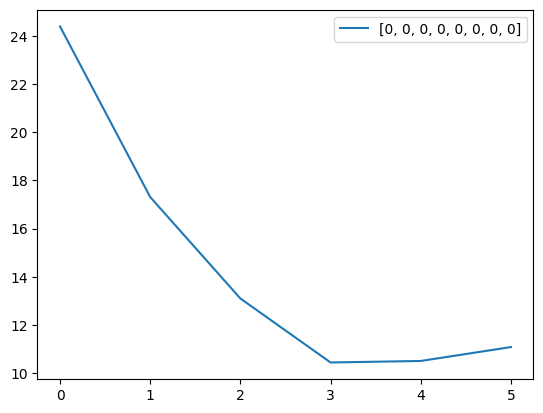

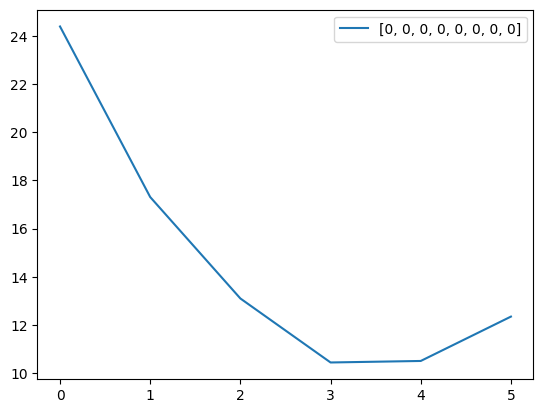

IndexError: list index out of range

In [ ]:


# for i in np.arange(4):
#     plt.plot(num_pass_for_schedule[i], qber_for_schedule[i], label = f"{many_block_schedules[i]}")
#     plt.legend()
#     plt.show()





def plot_files_scatter(file_list, title="Scatter Plot of File Data"):
    """
    Takes a list of file paths, extracts the first two columns, 
    and creates a scatter plot.
    """
    plt.figure(figsize=(10, 6))
    
    for file in file_list:
        try:
            # Load the file; handles CSV by default, but can be adjusted for tabs
            # use_cols=[0, 1] ensures we only pull the first two columns
            df = pd.read_csv(file, usecols=[0, 1], header=None)
            
            # Label the series based on the filename
            label = os.path.basename(file)
            
            plt.scatter(df.iloc[:, 0], df.iloc[:, 1], label=label, alpha=0.7)
            
        except Exception as e:
            print(f"Could not process file {file}: {e}")

    plt.title(title)
    plt.xlabel("Number of Passes")
    plt.ylabel("QBER")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

#Example Usage:

many_block_schedules = [
    [4,4,0,0,0,0,0,0],
    [4,2,2,0,0,0,0,0],
    [4,2,1,0,0,0,0,0],
    [8,4,1,0,0,0,0,0],
    [2,2,0,0,0,0,0,0],
    [1,1,0,0,0,0,0,0]
]

output_file_names = [
    'qber_pass_44000000.csv',
    'qber_pass_42200000.csv',
    'qber_pass_42100000.csv',
    'qber_pass_84100000.csv',
    'qber_pass_22000000.csv',
    'qber_pass_11000000.csv'
]
plot_files_scatter(output_file_names)
